# Tune, train, and validate classifiers

This notebook uses the training dataset created by notebook `00b` and the features selected in `01a` to tune hyperparameters, train, and validate the PU models.

Fold strategies are defined upfront, then `RandomizedSearchCV` on the spatial folds tunes the inner `RandomForestClassifier`. The tuned pipeline is evaluated via three cross-validation schemes and the final classifiers are fit on all data and saved.

## Notebook setup

These cells set some of the important variables and definitions used throughout the notebook, based on the selected config file.

### Config

In [49]:
config_file = "config/.run_config.yml"

In [50]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# =====================
# Filestructure
# =====================

# Base directories
plate_model_dir = pcm.PLATE_MODEL_DIR
points_data_dir = pcm.POINTS_DATA_DIR
output_dir = pcm.OUTPUT_DIR

pcm.create_directories()
pcm.CROSS_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
pcm.FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

# Input data filepaths
regions_filepath = pcm.REGIONS_PATH
training_data_filepath = pcm.TRAINING_DATA_PATH

# =====================
# Notebook scope
# =====================

# Gates for determining scope of notebook run (i.e. which feature sets can be selected from)
use_features = pcm.use_features

# If True, use training data extracted in notebook 00b, 00c
# Else, use pre-prepared training data downloaded from Zenodo
use_extracted_data = pcm.use_extracted_data

# If False, skip training the SVM models
create_svm = pcm.config["create_svm"]

# If False, skip training all regional models (PU and SVM)
create_regional_models = pcm.config["create_regional_models"]

# =====================
# Model training parameters
# =====================

# Timespan for plotting
min_time = pcm.config["timespan"]["min"]
max_time = pcm.config["timespan"]["max"]
times = range(min_time, max_time + 1)

# If this parameter is False, perform feature selection using all data for all models
# If True, perform feature selection for each model individually
use_same_features = pcm.config["use_same_features"]

# If this parameter is False, selected features must be specified below
# Otherwise, they will be selected automatically
automatic_feature_selection = pcm.config["automatic_feature_selection"]

# Random seed for reproducibility
random_seed = pcm.config["random_seed"]

# Number of processes to use
n_jobs = pcm.config["n_jobs"]

# Overwrite any existing output files
overwrite = pcm.config["overwrite_output"]

# Control verbosity level of logging output
verbose = pcm.config["verbose"]

### Imports

In [51]:
import json
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pulearn.bagging import BaggingPuClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, recall_score
from sklearn.model_selection import (
    LeaveOneGroupOut,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedGroupKFold,
)
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

from lib.check_files import check_prepared_data
from lib.misc import (
    format_feature_name,
)
from lib.pu import (
    PU_PARAMS,
    COLUMNS_TO_DROP,
    PRESERVATION_COLUMNS,
    # downsample_unlabelled,
)

# Use figure style template in config directory
plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")

# Suppress FutureWarning for some versions of pandas
pd.set_option('future.no_silent_downcasting', True)

# Suppress FutureWarning for some versions of Scikit-learn
%env PYTHONWARNINGS=ignore

# Suppress some other warnings
warnings.simplefilter("ignore", ConvergenceWarning)

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_55831/1321568547.py:45: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [52]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    print(f"Using prepared training data in {pcm.PREPARED_DATA_DIR}")
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    grid_data_filepath = prep_dir / "grid_data.csv"
    training_filepath = prep_dir / "training_data_global.csv"

pu_basename = pcm.CLASSIFIER_PATH.with_suffix("")
validation_dir = pcm.CROSS_VALIDATION_DIR
importance_dir = pcm.FEATURE_IMPORTANCE_DIR
importance_basename = importance_dir / "feature_importance"
selected_features_filepath = pcm.SELECTED_FEATURES_PATH
tuned_params_path = pcm.OUTPUT_DIR / "tuned_params.json"

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_6.0_deg_buffer


### Classifier parameters

These are classifier parameters that have been previously tuned. If you wish to tune them further, use the hyperparameter tuning section below. 

In [53]:
# Parameters for models
imputer_params = {
    "random_state": random_seed,
    "add_indicator": False,
}
rf_params = {
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
}
pu_params = {
    **PU_PARAMS,
    "n_jobs": n_jobs,
    "random_state": random_seed,
    "n_estimators": 50,
    "balanced_subsample": True,
}
svm_params = {
    "kernel": "rbf",
    "probability": True,
    "random_state": random_seed,
}

Define model and preprocessing pipeline:

In [54]:
pu_model = BaggingPuClassifier(
    RandomForestClassifier(**rf_params),
    **pu_params
)
preprocessing = make_pipeline(
    # IterativeImputer(**imputer_params),
    RobustScaler(),
    VarianceThreshold(),
)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('robustscaler', ...), ('variancethreshold', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


### Plotting setup & helpers

In [55]:
from lib.colours import region_colour

FW = 150 / 25.4  # Convert 150 mm to inches for figure width

In [56]:
_threshold_grid = np.linspace(0, 1, 100)
_recall_grid = np.linspace(0, 1, 100)

def plot_recall_curve(recall_pos, label, ax=None):
    """Plot recall of positives vs threshold for one fold."""
    if ax is None:
        _, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Recall (positives)")
    ax.plot(_threshold_grid, recall_pos, label=label)
    ax.legend()
    return ax

def plot_mean_recall_curve(recall_curve_sets, output_path, title=None, show_random_chance=False):
    """Plot mean ± IQR recall-vs-threshold for one or more fold sets and save.

    Parameters
    ----------
    recall_curve_sets : dict or pd.DataFrame
        Either a dict mapping a label to a list of recall-vs-threshold arrays
        (each of length matching ``_threshold_grid``), or a long-form DataFrame
        with columns ``threshold``, ``recall``, ``split``, ``fold`` as saved by
        the cross-validation cells.
    output_path : path-like
        Base path for saved figures (extensions ``.pdf`` and ``.png`` are
        appended automatically).
    title : str, optional
        Figure title.
    show_random_chance : bool, default False
        If True, overlay a light-grey diagonal line representing a random
        classifier (recall = 1 − threshold), plotted at the lowest z-order.
        When enabled, the area between each curve set's cross-validated mean
        and the random-chance line is computed and returned as a third element.

    Returns
    -------
    fig, ax
        When ``show_random_chance=False``.
    fig, ax, auc_vs_random : dict[str, float]
        When ``show_random_chance=True``.  ``auc_vs_random`` maps each label
        to the area between its mean recall curve and the random-chance line,
        computed via the trapezoidal rule over ``_threshold_grid``.
    """
    if isinstance(recall_curve_sets, pd.DataFrame):
        df = recall_curve_sets
        recall_curve_sets = {
            split: [grp.sort_values("threshold")["recall"].values
                    for _, grp in df[df["split"] == split].groupby("fold")]
            for split in df["split"].unique()
        }

    fig, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))

    # Random-chance baseline: recall = 1 - threshold
    random_chance = 1.0 - _threshold_grid

    if show_random_chance:
        ax.plot(
            _threshold_grid,
            random_chance,
            color="0.75",
            linewidth=1.0,
            linestyle="--",
            label="Random chance",
            zorder=1,
        )

    auc_vs_random = {}
    for label, curves in recall_curve_sets.items():
        recall_matrix = np.vstack(curves)
        mean_r = recall_matrix.mean(axis=0)
        p25 = np.percentile(recall_matrix, 25, axis=0)
        p75 = np.percentile(recall_matrix, 75, axis=0)
        (line,) = ax.plot(_threshold_grid, mean_r, label=label, zorder=2)
        ax.fill_between(_threshold_grid, p25, p75, alpha=0.2, color=line.get_color(), zorder=2)

        if show_random_chance:
            auc_vs_random[label] = float(np.trapz(mean_r - random_chance, _threshold_grid))

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Recall (positives)")
    if title:
        ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        fig.savefig(f"{output_path}{ext}", dpi=350, bbox_inches="tight")

    if show_random_chance:
        return fig, ax, auc_vs_random
    return fig, ax

def plot_mean_pr_curve(pr_curve_sets, output_path, title=None):
    """Plot mean ± IQR precision-recall curve for one or more fold sets and save.

    Each entry in pr_curve_sets maps a label to a list of (recall_vals, precision_vals)
    tuples as returned by sklearn.metrics.precision_recall_curve.
    """
    if isinstance(pr_curve_sets, pd.DataFrame):
        df = pr_curve_sets
        pr_curve_sets = {
            split: [grp.sort_values("threshold")["recall"].values
                    for _, grp in df[df["split"] == split].groupby("fold")]
            for split in df["split"].unique()
        }

    fig, ax = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    for label, curves in pr_curve_sets.items():
        # sklearn returns recall descending with a sentinel (recall=0, precision=1) appended.
        # Drop the sentinel and flip so recall is ascending for np.interp.
        precision_matrix = np.vstack([
            np.interp(_recall_grid, r[:-1][::-1], p[:-1][::-1])
            for r, p in curves
        ])
        mean_p = precision_matrix.mean(axis=0)
        p25 = np.percentile(precision_matrix, 25, axis=0)
        p75 = np.percentile(precision_matrix, 75, axis=0)
        (line,) = ax.plot(_recall_grid, mean_p, label=label)
        ax.fill_between(_recall_grid, p25, p75, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    if title:
        ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        fig.savefig(f"{output_path}{ext}", dpi=350, bbox_inches="tight")
    return fig, ax

## Training data

These cells load and plot the training data.

In [57]:
data = pd.read_csv(training_data_filepath)

data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'plate_transverse_velocity_upper_mantle_abs_max_value (cm/yr)',
       'plate_transverse_velocity_upper_mantle_depth_of_abs_max (km)',
       'temperature_deviation_upper_mantle_ref_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_ref_gradient_delta (K/km/Myr)',
       'temperature_deviation_upper_mantle_depth_integral_delta (K·km/Myr)',
       'temperature_deviation_upper_mantle_min_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_min_delta (km/Myr)',
       'temperature_deviation_upper_mantle_max_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_max_delta (km/Myr)',
       'region'],
      dtype='str', length=121)

### Columns to drop

In [58]:
# ---+ Coordinate columns --------------------------------------------------------

coordinate_columns = {
    "present_lon",
    "present_lat",
    "lon",
    "lat",
    "Cu (Mt)",
    "age (Ma)",
}


# ---+ Metadata columns --------------------------------------------------------

metadata_columns = {
    "region",
    "plate_id",
    "set",
    "source",
    "overriding_plate_id",
    "subducting_plate_ID",
    "trench_plate_ID",
    "arc_segment_length (degrees)",
    "trench_normal_angle (degrees)",
    "distance_from_trench_start (degrees)",
    "distance_from_trench_start (km)",
    "crustal_thickness_n",
    "bracket_infilled",
}


# ---+ Component columns --------------------------------------------------------

# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# Use orthogonal/parallel velocity vector components
component_columns |= {
    "subducting_plate_absolute_velocity (cm/yr)",
    "convergence_rate (cm/yr)",
    "trench_velocity (cm/yr)",
}
# Drop oceanic crust thickness and convergence rate,
# only use slab flux (product of the two components)
# component_columns |= {
#     "convergence_rate_orthogonal (cm/yr)",
#     "plate_thickness (m)",
# }
# Drop orthogonal components of mantle/plate velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}


# ---+ Preservation columns --------------------------------------------------------

preservation_columns = {
    "total_precipitation (km)",
    "total_convergence (km)",
    "erosion (m)",
}

# ---+ Final set for feature selection --------------------------------------------------------

columns_to_drop = coordinate_columns | metadata_columns | component_columns | preservation_columns

### Load training data

In [59]:
data = pd.read_csv(training_data_filepath)

# Remove duplicate points
# Duplicates arise from a one-to-many overriding-plate
# spatial join in combine_point_data() (notebook 00b).
# Deduplication prevents model bias from over-representation of certain locations.
data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits for regional models only.
# The global model *can* train on all deposits, including those outside region polygons.
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data_regional = data[~data["region"].isin(regions_to_skip)]
data = data[~data["region"].isin(regions_to_skip)]

cleaned = data.drop(
    columns=list(columns_to_drop),
    errors="ignore",
)
# del tmp, tmp_downsampled

print("Training data summary (global):")
print(data.groupby(["region", "label"]).size())
print("\nOverall class distribution (global):")
print(data.groupby(["label"]).size())

for column in cleaned.columns:
    if cleaned[column].isna().sum() > 0:
        print(f"{column}: {cleaned[column].dtype}, {cleaned[column].isna().sum()} missing values")

Training data summary (global):
region          label     
East Asia       negative         7
                positive       140
                unlabelled    5223
North America   negative        51
                positive       283
                unlabelled    6020
South America   negative       641
                positive       160
                unlabelled    6081
Southeast Asia  negative         2
                positive       123
                unlabelled    3927
Tethys          negative         5
                positive       281
                unlabelled    4831
dtype: int64

Overall class distribution (global):
label
negative        706
positive        987
unlabelled    26082
dtype: int64


### Wrangle training data

In [60]:
# Maintain a reference containing metadata fields
data_pu = data[data["label"].isin({"positive", "unlabelled"})]

# Wrangle the training data to the required format
train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
features_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

# Load the features selected in notebook 01a
selected_features = pd.read_csv(selected_features_filepath)["selected_features"].tolist()
X_pu = features_pu[selected_features]

In [61]:
X_pu

,plate_thickness (m),seafloor_spreading_rate (km/Myr),trench_velocity_parallel (cm/yr),trench_velocity_orthogonal (cm/yr),convergence_rate_parallel (cm/yr),convergence_rate_orthogonal (cm/yr),plate_acceleration (cm/yr/Myr),lab_depth (km),lab_depth_delta (km/Myr),temperature_deviation_lab_relative_ref_value (K),...,temperature_deviation_lab_relative_depth_of_min_delta (km/Myr),temperature_deviation_lab_relative_depth_of_max_delta (km/Myr),radial_velocity_lab_relative_ref_gradient (cm/yr/km),radial_velocity_lab_relative_min_value (cm/yr),radial_velocity_lab_relative_depth_of_min (km),radial_velocity_lab_relative_depth_of_max (km),tangential_speed_lab_relative_ref_value (cm/yr),tangential_speed_lab_relative_depth_of_max (km),plate_parallel_velocity_lab_relative_ref_gradient (cm/yr/km),plate_transverse_velocity_lab_relative_ref_gradient (cm/yr/km)
1625,106008.768082,136.000000,2.840341,1.433054,-0.795288,2.605258,0.002451,91.193934,-6.745215e-01,-419.172003,...,0.000000,-2.068966,-1.030472e-12,-1.251168e-09,300.000000,0.000000,3.046331,0.000000,-8.341032e-14,3.778470e-13
1627,101985.454559,65.228570,1.804855,7.622569,0.000000,0.000000,0.005993,133.058313,6.739972e-01,-499.723148,...,-3.103448,0.000000,-2.230176e-12,-8.526329e-10,186.206897,0.000000,3.469813,103.448276,-1.425402e-12,-6.786915e-12
1629,48146.009445,33.366974,0.471579,2.209116,0.000058,0.000274,0.034926,66.582940,2.013596e+00,-0.071525,...,-4.137931,-3.103448,-1.357184e-12,-2.796096e-10,93.103448,300.000000,3.175121,0.000000,-5.706073e-13,2.266631e-13
1630,48630.356789,32.442856,-0.593077,2.153801,-0.000021,0.000075,0.035380,79.656467,2.096249e+00,-120.086350,...,-4.137931,-4.137931,-3.897168e-12,-3.770231e-10,124.137931,300.000000,3.392842,0.000000,-1.260728e-12,1.118720e-13
1631,42473.554611,43.969696,-6.752194,-0.522108,6.556158,7.673128,0.043001,42.476100,4.955320e+00,-81.281399,...,-14.482759,19.655172,-5.005242e-12,-1.278460e-09,300.000000,0.000000,5.057652,0.000000,-7.412056e-13,3.429053e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39030,98484.992981,75.000000,7.327511,10.408895,-4.034371,4.144361,0.053022,62.921277,1.251175e+00,47.111970,...,-12.413793,0.000000,-2.093131e-12,-3.951907e-10,113.793103,0.000000,0.541940,155.172414,-1.047810e-11,-4.134949e-12
39031,95046.997070,75.000000,-3.775561,-2.578315,2.636287,6.827376,0.055028,19.937931,-1.751578e+00,290.393408,...,0.000000,1.034483,9.312293e-13,-2.189704e-10,300.000000,93.103448,11.321019,0.000000,1.722314e-11,-1.804715e-11
39032,99133.968353,75.000000,-3.787213,0.294994,3.754754,8.554488,0.026699,131.697147,2.427470e+00,-96.977279,...,0.000000,0.000000,2.099196e-13,2.529051e-12,0.000000,289.655172,5.604510,0.000000,-1.445192e-12,2.941813e-12
39033,63728.451729,75.000000,-0.700514,-4.451419,-9.395613,12.150869,0.005491,123.260476,9.692650e-01,-69.139487,...,0.000000,2.068966,2.113435e-14,-1.456725e-11,300.000000,175.862069,1.304889,113.793103,4.180894e-12,-3.274955e-12


## Define folds

### Standard K-Folds

In [62]:
n_folds = 5
n_repeats = 1

rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats, random_state=random_seed)

### Regional (leave-one-region-out)

In [63]:
# Align region_groups to X_pu's index
regions = data_pu.loc[X_pu.index, "region"]
region_groups, group_labels = pd.factorize(regions)

assert len(region_groups) == len(X_pu), "region_groups and X_pu are misaligned"

logo = LeaveOneGroupOut()

### Spatially-stratified

Divide the training data into a grid of 10° x 10° x 10Myr voxels. For each fold, 

In [64]:
lon_spacing, lat_spacing, time_spacing = 10, 10, 10

lon_grid = np.floor(data_pu["lon"] / lon_spacing) * lon_spacing
lat_grid = np.floor(data_pu["lat"] / lat_spacing) * lat_spacing
time_grid = np.floor(data_pu["age (Ma)"] / time_spacing) * time_spacing

spatial_groups, _ = pd.factorize(lon_grid + lat_grid * 100 + time_grid * 10000)

n_folds_spatial = 5
sgkf = StratifiedGroupKFold(n_splits=n_folds_spatial, shuffle=True, random_state=random_seed)

## Hyperparameter tuning

`RandomizedSearchCV` is run on the spatial CV folds to tune the inner `RandomForestClassifier` parameters. The tuned parameters are then used to rebuild the pipeline for all downstream cross-validation and training.

In [ ]:
tune_params = not tuned_params_path.is_file()
if tune_params:
    param_distributions = {
        "classifier__estimator__max_depth": [5, 8, 12, 20],
        "classifier__estimator__min_samples_leaf": [5, 10, 20, 50],
        "classifier__estimator__max_features": ["sqrt", 0.3, 0.5],
        "classifier__max_samples": [0.5, 0.7, 1.0],
    }

    def pu_scorer(estimator, X, y):
        return average_precision_score(y, estimator.predict_proba(X)[:, 1])

    outer_scores = []
    outer_best_params = []
    train_recall_curves = []
    test_recall_curves = []

    for train_idx, test_idx in logo.split(X_pu, y_pu, groups=region_groups):
        X_train, X_test = X_pu.iloc[train_idx], X_pu.iloc[test_idx]
        y_train, y_test = y_pu.iloc[train_idx], y_pu.iloc[test_idx]
        groups_train = spatial_groups[train_idx]

        inner_search = RandomizedSearchCV(
            clone(pu_pipeline),
            param_distributions,
            n_iter=20,
            scoring=pu_scorer,
            cv=sgkf,
            n_jobs=n_jobs,
            random_state=random_seed,
            refit=True,
            verbose=verbose,
        )
        inner_search.fit(X_train, y_train, groups=groups_train)

        best_model = inner_search.best_estimator_
        for X_s, y_s, store in [
            (X_test,  y_test,  test_recall_curves),
            (X_train, y_train, train_recall_curves),
        ]:
            proba = best_model.predict_proba(X_s)[:, 1]
            store.append([
                recall_score(y_s, (proba >= t).astype(int), zero_division=0)
                for t in _threshold_grid
            ])

        score = pu_scorer(best_model, X_test, y_test)
        outer_scores.append(score)
        outer_best_params.append(inner_search.best_params_)
        print(f"Fold AP: {score:.4f} | Best params: {inner_search.best_params_}")

    print(f"\nMean regional CV AP: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}")

    best_params = outer_best_params[np.argmax(outer_scores)]
    print(f"Best params (from best fold): {best_params}")

    fig, ax, auc_vs_random = plot_mean_recall_curve(
        {"Test (held-out)": test_recall_curves, "Train (in-sample)": train_recall_curves},
        output_path=validation_dir / "mean_recall_nested",
        title="Mean Recall vs Threshold:\nNested Regional Cross-Validation",
        show_random_chance=True,
    )

Fitting 5 folds for each of 20 candidates, totalling 100 fits


^^ Prev best: 0.5015 (0.3 max features, None max depth, 2 min samples split)

Verify that the inner `RandomForestClassifier` and outer `BaggingPuClassifier` n_estimators have converged — in both cases, more bags reduce variance but never increase bias, so we just need to confirm the scores plateau before the chosen value.

In [ ]:
if tune_params:
    import random
    _n_est_candidates = [1,5,10,20,50]
    print("RF bagger n_estimators convergence check (in-sample positive–unlabelled score gap):")
    for _n in _n_est_candidates:
        _m = clone(pu_pipeline)
        _m.set_params(classifier__estimator__n_estimators=_n)
        _m.set_params(classifier__random_state=random.randint(0, 10000))
        _m.fit(X_pu, y_pu)
        _s = _m.predict_proba(X_pu)[:, 1]
        _gap = _s[y_pu.values == 1].mean() - _s[y_pu.values == 0].mean()
        print(f"  n_estimators = {_n:>3d}: gap = {_gap:.4f}")

    rf_params["n_estimators"] = 50  # update once plateau is confirmed above

In [ ]:
if tune_params:
    _n_est_candidates = [1,5,10,20,50]
    print("PU bagger n_estimators convergence check (in-sample positive–unlabelled score gap):")
    for _n in _n_est_candidates:
        _m = clone(pu_pipeline)
        _m.set_params(classifier__n_estimators=_n)
        _m.set_params(classifier__random_state=random.randint(0, 10000))
        _m.fit(X_pu, y_pu)
        _s = _m.predict_proba(X_pu)[:, 1]
        _gap = _s[y_pu.values == 1].mean() - _s[y_pu.values == 0].mean()
        print(f"  n_estimators = {_n:>3d}: gap = {_gap:.4f}")

    pu_params["n_estimators"] = 50  # update once plateau is confirmed above

In [ ]:
if tune_params:
    with open(tuned_params_path, "w") as f:
        json.dump(
            {k: (int(v) if isinstance(v, np.integer) else v) for k, v in best_params.items()},
            f,
            indent=2,
        )
    print(f"Saved tuned params to {tuned_params_path}")

### Tuning results

In [ ]:
if tune_params:
    results_df = pd.DataFrame(outer_best_params)
    results_df["region"] = group_labels
    results_df["ap_score"] = outer_scores
    results_df = results_df.rename(columns={
        "classifier__estimator__max_depth":    "max_depth",
        "classifier__estimator__min_samples_leaf": "min_samples_leaf",
        "classifier__estimator__max_features": "max_features",
        "classifier__max_samples":             "max_samples",
    })

    fig, ax = plt.subplots(figsize=(FW * 0.6, FW * 0.35))
    bars = ax.bar(
    results_df["region"],
    results_df["ap_score"],
    color=[region_colour(r, "dark") for r in results_df["region"]],
    alpha=0.8,
)
    ax.axhline(np.mean(outer_scores), linestyle="--", color="0.4", linewidth=1.0, label=f"Mean AP: {np.mean(outer_scores):.3f}")
    ax.set_ylabel("Average Precision")
    ax.set_xlabel("Held-out Region")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(linestyle="dotted", axis="y")
    ax.legend()
    fig.suptitle("Nested Regional CV: Per-fold AP Scores")
    plt.tight_layout()
    for ext in (".pdf", ".png"):
        fig.savefig(f"{validation_dir / 'tuning_results'}{ext}", dpi=350, bbox_inches="tight")

    display(results_df[["region", "ap_score", "max_depth", "min_samples_leaf", "max_features", "max_samples"]].to_string(index=False))

### Rebuild pipeline with tuned parameters

In [ ]:
with open(tuned_params_path) as f:
    best_params = json.load(f)

rf_params_tuned = {
    **rf_params,
    "max_depth":       best_params.get("classifier__estimator__max_depth", None),
    "max_features":    best_params.get("classifier__estimator__max_features", "sqrt"),
    "min_samples_leaf": best_params.get("classifier__estimator__min_samples_leaf", 1),
}
pu_params_tuned = {
    **pu_params,
    "max_samples": best_params.get("classifier__max_samples", 1.0),
}

pu_model = BaggingPuClassifier(RandomForestClassifier(**rf_params_tuned), **pu_params_tuned)
pu_pipeline = Pipeline([("preprocessing", preprocessing), ("classifier", pu_model)])
pu_pipeline.set_output(transform="pandas")
print(f"Pipeline rebuilt with tuned parameters from {tuned_params_path}:")
print(f"  RF max_depth          = {rf_params_tuned['max_depth']}")
print(f"  RF max_features       = {rf_params_tuned['max_features']}")
print(f"  RF min_samples_leaf   = {rf_params_tuned['min_samples_leaf']}")
print(f"  RF n_estimators       = {rf_params_tuned['n_estimators']} (fixed)")
print(f"  PU max_samples        = {pu_params_tuned['max_samples']}")
print(f"  PU n_estimators       = {pu_params_tuned['n_estimators']} (convergence-checked)")

### Regional classifiers

In [ ]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = region.lower().replace(" ", "_")
        tuned_params_path_r = pcm.OUTPUT_DIR / f"tuned_params_{r}.json"

        if tuned_params_path_r.exists():
            print(f"[{region}] Skipping tuning — {tuned_params_path_r.name} already exists")
            continue

        # Region-specific features
        region_features = pd.read_csv(
            selected_features_filepath.with_name(f"{selected_features_filepath.stem}_{r}.csv")
        )["selected_features"].tolist()

        # Build X_r, y_r
        subset = data_regional[
            (data_regional["region"] == region)
            & data_regional["label"].isin({"positive", "unlabelled"})
        ]
        subset_cleaned = cleaned[cleaned.index.isin(subset.index)]
        X_r = subset_cleaned.drop(columns="label")[region_features]
        y_r = subset_cleaned["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

        # Spatial groups aligned to X_r (same formula as spatially-stratified CV cell)
        meta_r = data_pu.loc[X_r.index]
        spatial_groups_r, _ = pd.factorize(
            np.floor(meta_r["lon"] / 10) * 10
            + np.floor(meta_r["lat"] / 10) * 100
            + np.floor(meta_r["age (Ma)"] / 10) * 10000
        )

        param_distributions = {
            "classifier__estimator__max_depth": [5, 8, 12, 20],
            "classifier__estimator__min_samples_leaf": [5, 10, 20, 50],
            "classifier__estimator__max_features": ["sqrt", 0.3, 0.5],
            "classifier__max_samples": [0.5, 0.7, 1.0],
        }

        def pu_scorer(estimator, X, y):
            return average_precision_score(y, estimator.predict_proba(X)[:, 1])

        outer_scores_r = []
        outer_best_params_r = []
        train_recall_curves_r = []
        test_recall_curves_r = []

        for train_idx, test_idx in sgkf.split(X_r, y_r, groups=spatial_groups_r):
            X_train_r, X_test_r = X_r.iloc[train_idx], X_r.iloc[test_idx]
            y_train_r, y_test_r = y_r.iloc[train_idx], y_r.iloc[test_idx]
            groups_train_r = spatial_groups_r[train_idx]

            inner_search_r = RandomizedSearchCV(
                clone(pu_pipeline),
                param_distributions,
                n_iter=20,
                scoring=pu_scorer,
                cv=sgkf,
                n_jobs=n_jobs,
                random_state=random_seed,
                refit=True,
                verbose=verbose,
            )
            inner_search_r.fit(X_train_r, y_train_r, groups=groups_train_r)

            best_model_r = inner_search_r.best_estimator_
            for X_s, y_s, store in [
                (X_test_r,  y_test_r,  test_recall_curves_r),
                (X_train_r, y_train_r, train_recall_curves_r),
            ]:
                proba = best_model_r.predict_proba(X_s)[:, 1]
                store.append([
                    recall_score(y_s, (proba >= t).astype(int), zero_division=0)
                    for t in _threshold_grid
                ])

            score_r = pu_scorer(best_model_r, X_test_r, y_test_r)
            outer_scores_r.append(score_r)
            outer_best_params_r.append(inner_search_r.best_params_)
            print(f"[{region}] Fold AP: {score_r:.4f} | Best params: {inner_search_r.best_params_}")

        print(f"\n[{region}] Mean spatial CV AP: {np.mean(outer_scores_r):.4f} ± {np.std(outer_scores_r):.4f}")
        best_params_r = outer_best_params_r[np.argmax(outer_scores_r)]
        print(f"[{region}] Best params (from best fold): {best_params_r}")

        plot_mean_recall_curve(
            {"Test (held-out)": test_recall_curves_r, "Train (in-sample)": train_recall_curves_r},
            output_path=validation_dir / f"mean_recall_nested_{r}",
            title=f"Mean Recall vs Threshold:\nNested Spatial CV ({region})",
            show_random_chance=True,
        )

        with open(tuned_params_path_r, "w") as f:
            json.dump(
                {k: (int(v) if isinstance(v, np.integer) else v) for k, v in best_params_r.items()},
                f,
                indent=2,
            )
        print(f"[{region}] Saved tuned params to {tuned_params_path_r}")

## Cross-validation

In [24]:
plot_recall_threshold_curve = True   # plot recall-vs-threshold curves for each CV scheme
plot_pr_curve = False                 # plot precision-recall curves for each CV scheme

In [25]:
recall_dict = {}
ap_scores = []

### In-sample score distribution

Fits the model on all training data and checks that the model assigns higher scores to known positives than to unlabelled samples. Not a measure of generalisation, but confirms the model is learning a useful signal.

In [26]:
pu_pipeline.fit(X_pu, y_pu)
y_scores = pu_pipeline.predict_proba(X_pu)[:, 1]
pos_scores = y_scores[y_pu.values == 1]
unl_scores = y_scores[y_pu.values == 0]
print("In-sample score distribution (sanity check):")
print(f"  Positives  — median: {np.median(pos_scores):.3f}, mean: {np.mean(pos_scores):.3f}")
print(f"  Unlabelled — median: {np.median(unl_scores):.3f}, mean: {np.mean(unl_scores):.3f}")

In-sample score distribution (sanity check):
  Positives  — median: 0.946, mean: 0.917
  Unlabelled — median: 0.280, mean: 0.291


### Standard K-Folds cross-validation

Baseline cross-validation with no spatial or geological grouping structure.

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


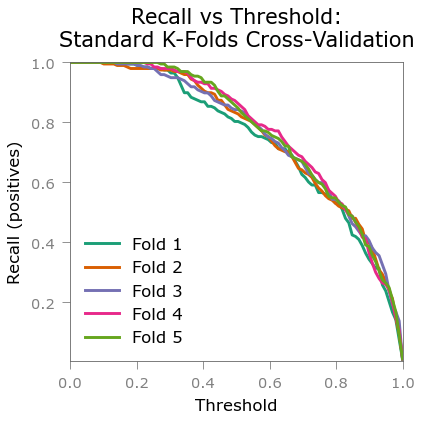

In [27]:
if plot_recall_threshold_curve:
    fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    ax_r.set_xlabel("Threshold")
    ax_r.set_ylabel("Recall (positives)")
    ax_r.set_title("Recall vs Threshold:\nStandard K-Folds Cross-Validation")

test_recall_curves = []
train_recall_curves = []
test_pr_curves = []
for fold, (train_index, test_index) in enumerate(rskf.split(X_pu, y_pu)):
    X_train, X_test = X_pu.iloc[train_index], X_pu.iloc[test_index]
    y_train, y_test = y_pu.iloc[train_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    fold_label = f"R{fold // n_folds + 1}/Fold {fold % n_folds + 1}" if n_repeats > 1 else f"Fold {fold + 1}"
    print(fold_label)
    ap_scores.append({"scheme": "standard", "fold": fold_label, "ap": average_precision_score(y_test, y_scores)})

    if plot_recall_threshold_curve:
        recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
        plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
        test_recall_curves.append(recall_pos)
        train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

    if plot_pr_curve:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_scores)
        test_pr_curves.append((rec_vals, prec_vals))

if plot_recall_threshold_curve:
    fig_r.tight_layout()

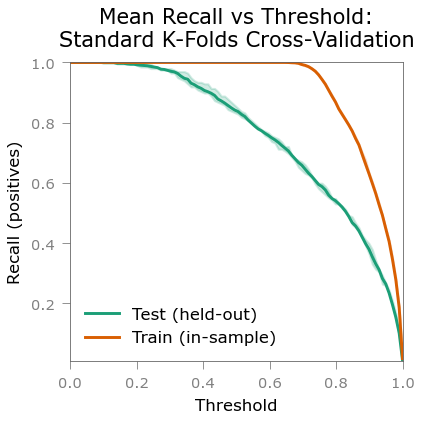

In [28]:
if plot_recall_threshold_curve:
    _standard_recall_sets = {
        "Test (held-out)": test_recall_curves,
        "Train (in-sample)": train_recall_curves,
    }
    recall_dict["standard"] = _standard_recall_sets
    plot_mean_recall_curve(
        _standard_recall_sets,
        validation_dir / "mean_recall_standard",
        title="Mean Recall vs Threshold:\nStandard K-Folds Cross-Validation",
    )

if plot_pr_curve:
    plot_mean_pr_curve(
        {"Test (held-out)": test_pr_curves},
        validation_dir / "mean_pr_standard",
        title="Mean Precision-Recall:\nStandard K-Folds Cross-Validation",
    )

North America: mean AP = 0.7982
South America: mean AP = 0.7229
East Asia: mean AP = 0.8905
Southeast Asia: mean AP = 0.7429
Tethys: mean AP = 0.8322


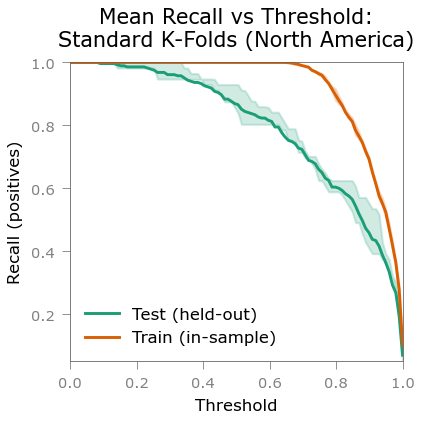

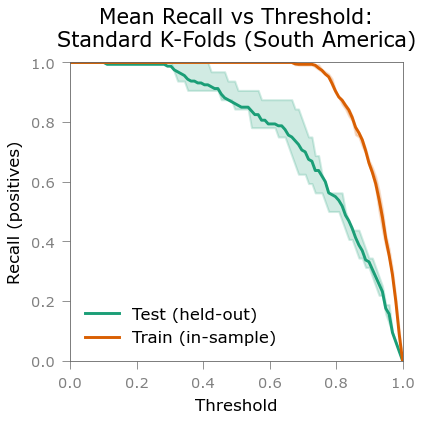

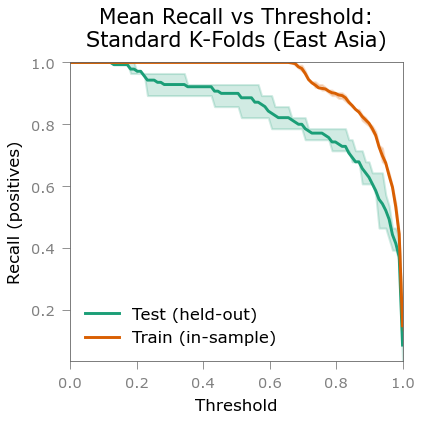

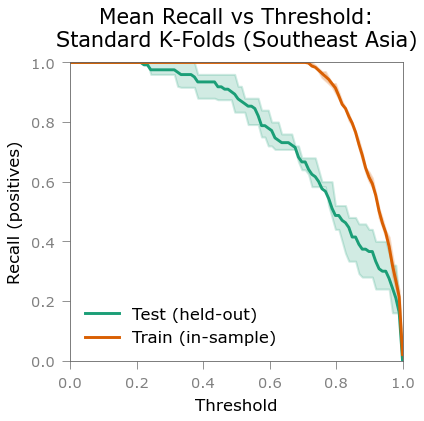

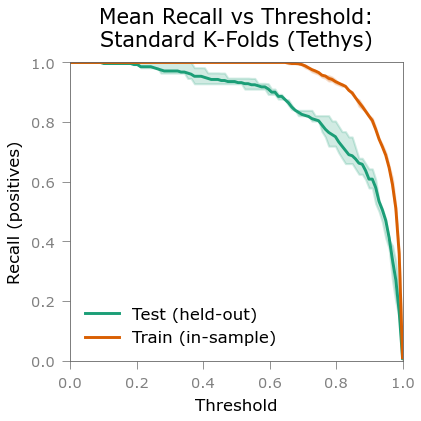

In [29]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = region.lower().replace(" ", "_")
        region_features = pd.read_csv(
            selected_features_filepath.with_name(f"{selected_features_filepath.stem}_{r}.csv")
        )["selected_features"].tolist()

        subset = data_regional[
            (data_regional["region"] == region)
            & data_regional["label"].isin({"positive", "unlabelled"})
        ]
        subset_cleaned = cleaned[cleaned.index.isin(subset.index)]
        X_r = subset_cleaned.drop(columns="label")[region_features]
        y_r = subset_cleaned["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

        scores, test_rc, train_rc = [], [], []
        for fold, (train_idx, test_idx) in enumerate(rskf.split(X_r, y_r)):
            fold_label = f"R{fold // n_folds + 1}/Fold {fold % n_folds + 1}" if n_repeats > 1 else f"Fold {fold + 1}"
            pipe = clone(pu_pipeline).fit(X_r.iloc[train_idx], y_r.iloc[train_idx])
            y_scores = pipe.predict_proba(X_r.iloc[test_idx])[:, 1]
            scores.append({"scheme": "standard", "fold": fold_label, "ap": average_precision_score(y_r.iloc[test_idx], y_scores)})
            if plot_recall_threshold_curve:
                test_rc.append((y_scores[y_r.iloc[test_idx].values == 1][:, None] >= _threshold_grid).mean(axis=0))
                train_rc.append((pipe.predict_proba(X_r.iloc[train_idx])[:, 1][y_r.iloc[train_idx].values == 1][:, None] >= _threshold_grid).mean(axis=0))

        pd.DataFrame(scores).to_csv(pcm.CROSS_VALIDATION_DIR / f"ap_scores_standard_{r}.csv", index=False)
        if plot_recall_threshold_curve:
            rc_sets = {"Test (held-out)": test_rc, "Train (in-sample)": train_rc}
            plot_mean_recall_curve(rc_sets, validation_dir / f"mean_recall_standard_{r}",
                                   title=f"Mean Recall vs Threshold:\nStandard K-Folds ({region})")
            pd.concat(
                [pd.DataFrame({"threshold": _threshold_grid, "recall": c, "split": s, "fold": i})
                 for s, curves in rc_sets.items() for i, c in enumerate(curves)],
                ignore_index=True,
            ).to_csv(pcm.CROSS_VALIDATION_DIR / f"recall_curves_standard_{r}.csv", index=False)
        print(f"{region}: mean AP = {pd.DataFrame(scores)['ap'].mean():.4f}")

### Regional cross-validation

Hold one region's points out and train the classifier on the rest of the regions. Use the held-out region for testing.

Fold: Tethys
Fold: Southeast Asia
Fold: North America
Fold: South America
Fold: East Asia


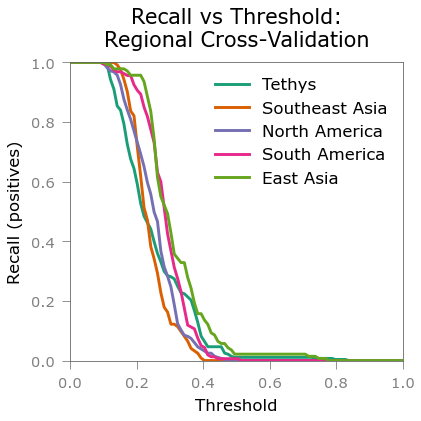

In [30]:
if plot_recall_threshold_curve:
    fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    ax_r.set_xlabel("Threshold")
    ax_r.set_ylabel("Recall (positives)")
    ax_r.set_title("Recall vs Threshold:\nRegional Cross-Validation")

test_recall_curves = []
train_recall_curves = []
test_pr_curves = []
for train_index, test_index in logo.split(X_pu, groups=region_groups):
    X_train, X_test = X_pu.iloc[train_index], X_pu.iloc[test_index]
    y_train, y_test = y_pu.iloc[train_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    fold_label = regions.iloc[test_index].iloc[0]
    print(f"Fold: {fold_label}")
    ap_scores.append({"scheme": "regional", "fold": fold_label, "ap": average_precision_score(y_test, y_scores)})

    if plot_recall_threshold_curve:
        recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
        plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
        test_recall_curves.append(recall_pos)
        train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

    if plot_pr_curve:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_scores)
        test_pr_curves.append((rec_vals, prec_vals))

if plot_recall_threshold_curve:
    fig_r.tight_layout()

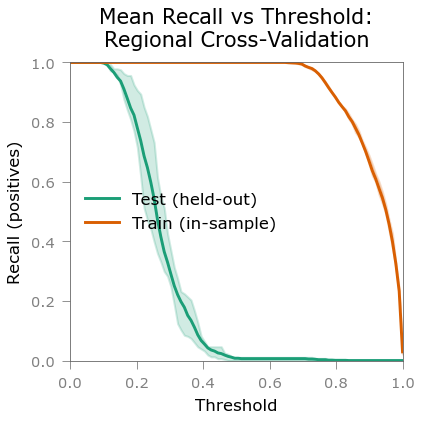

In [31]:
if plot_recall_threshold_curve:
    _regional_recall_sets = {
        "Test (held-out)": test_recall_curves,
        "Train (in-sample)": train_recall_curves,
    }
    recall_dict["regional"] = _regional_recall_sets
    plot_mean_recall_curve(
        _regional_recall_sets,
        validation_dir / "mean_recall_regional",
        title="Mean Recall vs Threshold:\nRegional Cross-Validation",
    )

if plot_pr_curve:
    plot_mean_pr_curve(
        {"Test (held-out)": test_pr_curves},
        validation_dir / "mean_pr_regional",
        title="Mean Precision-Recall:\nRegional Cross-Validation",
    )

### Spatially-stratified cross-validation

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


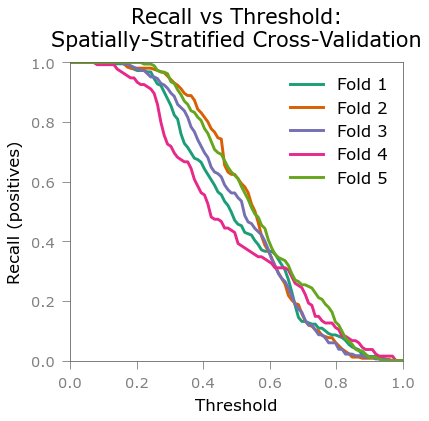

In [32]:
if plot_recall_threshold_curve:
    fig_r, ax_r = plt.subplots(figsize=(FW * 0.5, FW * 0.5))
    ax_r.set_xlabel("Threshold")
    ax_r.set_ylabel("Recall (positives)")
    ax_r.set_title("Recall vs Threshold:\nSpatially-Stratified Cross-Validation")

test_recall_curves = []
train_recall_curves = []
test_pr_curves = []
for fold, (train_index, test_index) in enumerate(sgkf.split(X_pu, y_pu, groups=spatial_groups)):
    X_train, y_train = X_pu.iloc[train_index], y_pu.iloc[train_index]
    X_test, y_test = X_pu.iloc[test_index], y_pu.iloc[test_index]
    pu_pipeline.fit(X_train, y_train)
    y_scores = pu_pipeline.predict_proba(X_test)[:, 1]
    fold_label = f"Fold {fold + 1}"
    print(fold_label)
    ap_scores.append({"scheme": "spatial", "fold": fold_label, "ap": average_precision_score(y_test, y_scores)})

    if plot_recall_threshold_curve:
        recall_pos = (y_scores[y_test.values == 1][:, None] >= _threshold_grid).mean(axis=0)
        plot_recall_curve(recall_pos, label=fold_label, ax=ax_r)
        test_recall_curves.append(recall_pos)
        train_recall_curves.append((pu_pipeline.predict_proba(X_train)[:, 1][y_train.values == 1][:, None] >= _threshold_grid).mean(axis=0))

    if plot_pr_curve:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_scores)
        test_pr_curves.append((rec_vals, prec_vals))

if plot_recall_threshold_curve:
    fig_r.tight_layout()

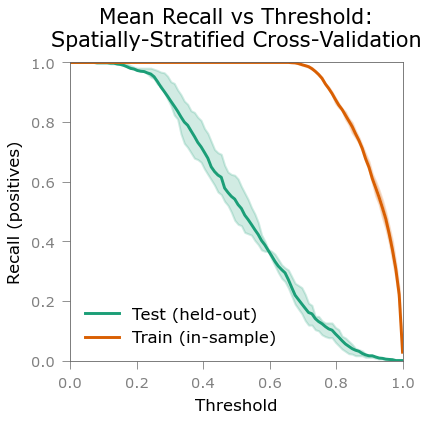

In [33]:
if plot_recall_threshold_curve:
    _spatial_recall_sets = {
        "Test (held-out)": test_recall_curves,
        "Train (in-sample)": train_recall_curves,
    }
    recall_dict["spatial"] = _spatial_recall_sets
    plot_mean_recall_curve(
        _spatial_recall_sets,
        validation_dir / "mean_recall_spatial",
        title="Mean Recall vs Threshold:\nSpatially-Stratified Cross-Validation",
    )

if plot_pr_curve:
    plot_mean_pr_curve(
        {"Test (held-out)": test_pr_curves},
        validation_dir / "mean_pr_spatial",
        title="Mean Precision-Recall:\nSpatially-Stratified Cross-Validation",
    )

North America: mean AP = 0.4599
South America: mean AP = 0.3396
East Asia: mean AP = 0.5169
Southeast Asia: mean AP = 0.3880
Tethys: mean AP = 0.6339


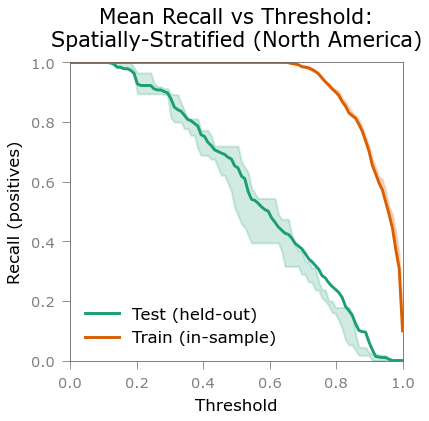

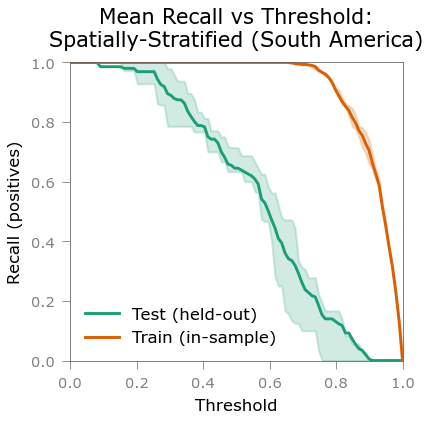

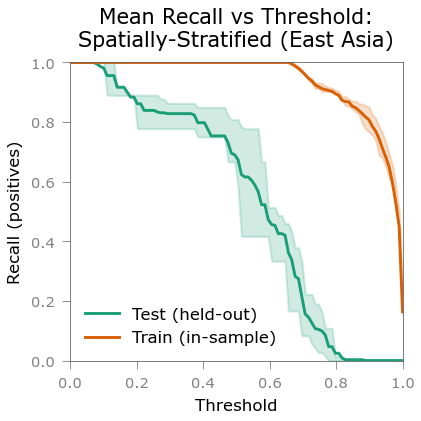

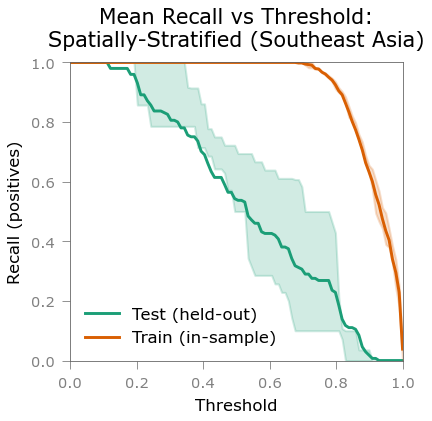

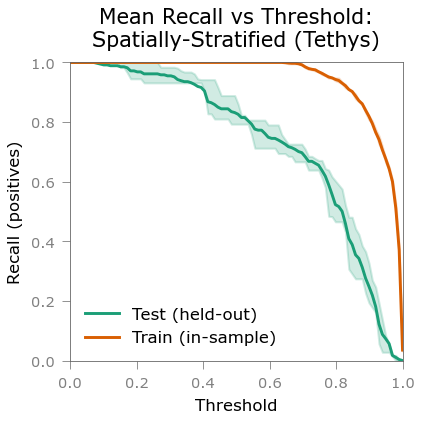

In [34]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = region.lower().replace(" ", "_")
        region_features = pd.read_csv(
            selected_features_filepath.with_name(f"{selected_features_filepath.stem}_{r}.csv")
        )["selected_features"].tolist()

        subset = data_regional[
            (data_regional["region"] == region)
            & data_regional["label"].isin({"positive", "unlabelled"})
        ]
        subset_cleaned = cleaned[cleaned.index.isin(subset.index)]
        X_r = subset_cleaned.drop(columns="label")[region_features]
        y_r = subset_cleaned["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

        # Recompute spatial groups for this region, aligned to X_r
        meta = data_pu.loc[X_r.index]
        spatial_groups_r, _ = pd.factorize(
            np.floor(meta["lon"] / 10) * 10
            + np.floor(meta["lat"] / 10) * 100
            + np.floor(meta["age (Ma)"] / 10) * 10000
        )

        scores, test_rc, train_rc = [], [], []
        try:
            for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_r, y_r, groups=spatial_groups_r)):
                pipe = clone(pu_pipeline).fit(X_r.iloc[train_idx], y_r.iloc[train_idx])
                y_scores = pipe.predict_proba(X_r.iloc[test_idx])[:, 1]
                scores.append({"scheme": "spatial", "fold": f"Fold {fold + 1}", "ap": average_precision_score(y_r.iloc[test_idx], y_scores)})
                if plot_recall_threshold_curve:
                    test_rc.append((y_scores[y_r.iloc[test_idx].values == 1][:, None] >= _threshold_grid).mean(axis=0))
                    train_rc.append((pipe.predict_proba(X_r.iloc[train_idx])[:, 1][y_r.iloc[train_idx].values == 1][:, None] >= _threshold_grid).mean(axis=0))
        except ValueError as e:
            print(f"Skipping spatial CV for {region}: {e}")
            continue

        pd.DataFrame(scores).to_csv(pcm.CROSS_VALIDATION_DIR / f"ap_scores_spatial_{r}.csv", index=False)
        if plot_recall_threshold_curve:
            rc_sets = {"Test (held-out)": test_rc, "Train (in-sample)": train_rc}
            plot_mean_recall_curve(rc_sets, validation_dir / f"mean_recall_spatial_{r}",
                                   title=f"Mean Recall vs Threshold:\nSpatially-Stratified ({region})")
            pd.concat(
                [pd.DataFrame({"threshold": _threshold_grid, "recall": c, "split": s, "fold": i})
                 for s, curves in rc_sets.items() for i, c in enumerate(curves)],
                ignore_index=True,
            ).to_csv(pcm.CROSS_VALIDATION_DIR / f"recall_curves_spatial_{r}.csv", index=False)
        print(f"{region}: mean AP = {pd.DataFrame(scores)['ap'].mean():.4f}")

In [35]:
if plot_recall_threshold_curve:
    for scheme_name, recall_sets in recall_dict.items():
        rows = []
        for split_label, curves in recall_sets.items():
            for fold_idx, curve in enumerate(curves):
                rows.append(pd.DataFrame({
                    "threshold": _threshold_grid,
                    "recall": curve,
                    "split": split_label,
                    "fold": fold_idx,
                }))
        pd.concat(rows, ignore_index=True).to_csv(
            pcm.CROSS_VALIDATION_DIR / f"recall_curves_{scheme_name}.csv", index=False
        )

if ap_scores:
    pd.DataFrame(ap_scores).to_csv(pcm.CV_AP_SCORES_PATH, index=False)

## Train and save classifiers

Fit the final classifiers on all training data using the tuned parameters, then save to disk.

### Global classifier

In [36]:
pu_pipeline.fit(X_pu, y_pu)
_ = joblib.dump(pu_pipeline, pu_basename.with_suffix(".joblib"), compress=True)
print(f"Saved global classifier to {pu_basename.with_suffix('.joblib')}")

Saved global classifier to /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/all_features/classifier.joblib


### Regional classifiers

Regional models reuse the hyperparameters tuned for the global model.

In [37]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = "_".join(region.lower().split())
        region_features_path = selected_features_filepath.with_name(
            f"{selected_features_filepath.stem}_{region.lower().replace(' ', '_')}.csv"
        )
        region_features = pd.read_csv(region_features_path)["selected_features"].tolist()

        subset = data_regional[data_regional["region"] == region]
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]
        subset_cleaned = cleaned[cleaned.index.isin(subset.index)]
        X_pu_region = subset_cleaned.drop(columns="label")[region_features]
        y_pu_region = subset_cleaned["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

        regional_pipeline = clone(pu_pipeline)
        regional_pipeline.fit(X_pu_region, y_pu_region)
        region_filename = f"{pu_basename.stem}_{r}.joblib"
        _ = joblib.dump(regional_pipeline, pu_basename.with_name(region_filename), compress=True)
        print(f"Saved {region} classifier")

Saved North America classifier
Saved South America classifier
Saved East Asia classifier
Saved Southeast Asia classifier
Saved Tethys classifier
